# Image Processing – Canny, Sobel & Noise Tests

In [6]:
%pip install -r requirements.txt

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Module 1 – Import Libraries (No Built-in Edge Detection)

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:

# ---------------------------------------------------------
# SCRATCH IMPLEMENTATION FUNCTIONS
# No cv2.Sobel() and no cv2.Canny() are used.
# ---------------------------------------------------------

def manual_convolution(image, kernel):
    image = image.astype(np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2

    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="constant")
    output = np.zeros_like(image, dtype=np.float64)

    # Flip kernel for convolution
    kernel = np.flipud(np.fliplr(kernel))

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output


# Standard Sobel kernels
SOBEL_X = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float64)

SOBEL_Y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float64)


def sobel_scratch(image):
    # Same idea as Sobel: calculate X and Y gradients manually
    gx = manual_convolution(image, SOBEL_X)
    gy = manual_convolution(image, SOBEL_Y)

    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    return gx, gy, magnitude


def normalize_image(image):
    image = np.abs(image)
    maximum = image.max()

    if maximum == 0:
        return np.zeros_like(image, dtype=np.uint8)

    return np.uint8(np.clip((image / maximum) * 255, 0, 255))


def gaussian_kernel(size=5, sigma=1.0):
    axis = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(axis, axis)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()

    return kernel


def gaussian_blur_scratch(image, size=5, sigma=1.0):
    kernel = gaussian_kernel(size, sigma)
    return manual_convolution(image, kernel)


def gradient_scratch(image):
    gx = manual_convolution(image, SOBEL_X)
    gy = manual_convolution(image, SOBEL_Y)

    magnitude = np.sqrt(gx**2 + gy**2)

    angle = np.rad2deg(np.arctan2(gy, gx))
    angle[angle < 0] += 180

    return gx, gy, magnitude, angle


def non_maximum_suppression(magnitude, angle):
    rows, cols = magnitude.shape
    result = np.zeros_like(magnitude)

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):

            direction = angle[i, j]
            current = magnitude[i, j]

            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                n1 = magnitude[i, j + 1]
                n2 = magnitude[i, j - 1]

            elif 22.5 <= direction < 67.5:
                n1 = magnitude[i - 1, j + 1]
                n2 = magnitude[i + 1, j - 1]

            elif 67.5 <= direction < 112.5:
                n1 = magnitude[i - 1, j]
                n2 = magnitude[i + 1, j]

            else:
                n1 = magnitude[i - 1, j - 1]
                n2 = magnitude[i + 1, j + 1]

            if current >= n1 and current >= n2:
                result[i, j] = current

    return result


def double_threshold(image, low=100, high=200):
    strong = 255
    weak = 75

    result = np.zeros_like(image, dtype=np.uint8)

    result[image >= high] = strong
    result[(image >= low) & (image < high)] = weak

    return result


def hysteresis_scratch(image):
    strong = 255
    weak = 75

    result = image.copy()
    rows, cols = result.shape

    changed = True

    while changed:
        changed = False

        for i in range(1, rows - 1):
            for j in range(1, cols - 1):

                if result[i, j] == weak:
                    neighborhood = result[i-1:i+2, j-1:j+2]

                    if np.any(neighborhood == strong):
                        result[i, j] = strong
                        changed = True

    result[result != strong] = 0
    return result


def canny_scratch(image, low=100, high=200):
    # 1. Gaussian smoothing
    blurred = gaussian_blur_scratch(image, size=5, sigma=1.0)

    # 2. Gradient calculation
    gx, gy, magnitude, angle = gradient_scratch(blurred)

    # 3. Non-maximum suppression
    nms = non_maximum_suppression(magnitude, angle)

    # 4. Double threshold
    thresholded = double_threshold(nms, low, high)

    # 5. Hysteresis
    edges = hysteresis_scratch(thresholded)

    return edges


print("Scratch Sobel and Canny functions defined successfully.")


Scratch Sobel and Canny functions defined successfully.


## Module 2 – Load Image

In [9]:
img = cv2.imread(r"c:\Users\rakul\OneDrive\Documents\Desktop\single-fresh-red-strawberry-on-table-green-background-food-fruit-sweet-macro-juicy-plant-image-photo.jpg", 0)

print("Image loaded successfully")
print("Image shape:", img.shape)

Image loaded successfully
Image shape: (350, 642)


## Module 3 – Display Original Image

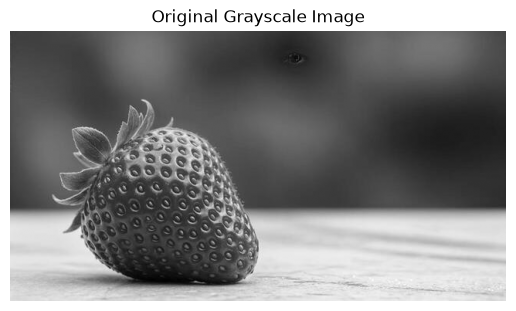

In [10]:
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

## Module 4 – Display Original Image Matrix

In [11]:
print("Original Image Matrix:")
print(img)

Original Image Matrix:
[[ 62  67  67 ...  69  69  69]
 [ 61  65  65 ...  69  69  69]
 [ 59  63  63 ...  70  69  69]
 ...
 [217 216 215 ... 220 223 223]
 [219 218 217 ... 219 222 222]
 [220 219 219 ... 220 221 221]]


## Module 5 – Canny Edge Detection – Scratch

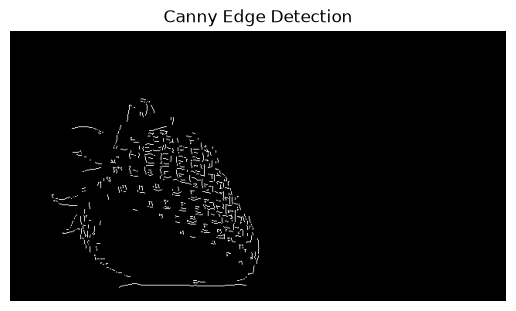

In [12]:
canny = canny_scratch(img, 100, 200)

plt.imshow(canny, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

## Module 6 – Canny Matrix

In [13]:
print("Canny Matrix:")
print(canny)

Canny Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Module 7 – Sobel Edge Detection – Scratch

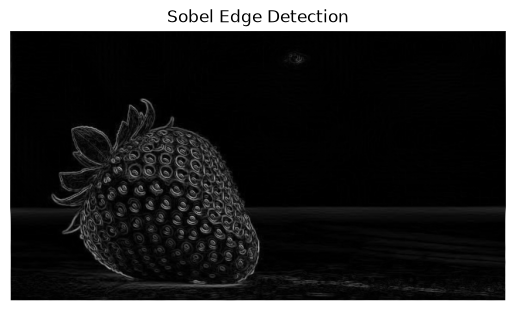

In [14]:
sobel = sobel_scratch(img)[2]

plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")
plt.show()

## Module 8 – Sobel Matrix

In [15]:
print("Sobel Matrix:")
print(sobel)

Sobel Matrix:
[[273.07508125 256.38252671 256.49951267 ... 277.01624501 276.
  292.74220741]
 [260.19223663  22.6715681   20.         ...   4.47213595   1.41421356
  276.        ]
 [252.07141845  18.38477631  13.03840481 ...   5.65685425   4.47213595
  277.01624501]
 ...
 [866.02078497  11.3137085   11.3137085  ...  12.08304597   9.05538514
  889.00506185]
 [871.04649704  14.76482306  16.55294536 ...  13.34166406  11.66190379
  888.02027004]
 [927.72409692 872.00917426 868.00921654 ... 878.03644571 885.01412418
  940.4530823 ]]


## Module – Gaussian Noise 10

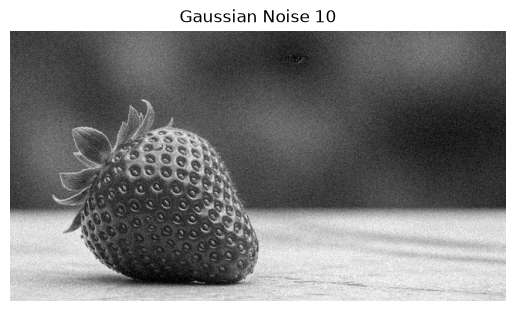

In [16]:
noise10 = np.random.normal(0, 10, img.shape)
gaussian10 = np.uint8(np.clip(img + noise10, 0, 255))

plt.imshow(gaussian10, cmap="gray")
plt.title("Gaussian Noise 10")
plt.axis("off")
plt.show()

## Gaussian Noise 10 Matrix

In [17]:
print("Gaussian Noise 10 Matrix:")
print(gaussian10)

Gaussian Noise 10 Matrix:
[[ 58  83  71 ...  68  46  76]
 [ 45  62  74 ...  73  84  71]
 [ 55  57  60 ...  57  79  84]
 ...
 [211 192 229 ... 212 233 222]
 [229 197 215 ... 210 225 221]
 [208 216 236 ... 227 227 222]]


## Canny – Scratch – Gaussian Noise 10

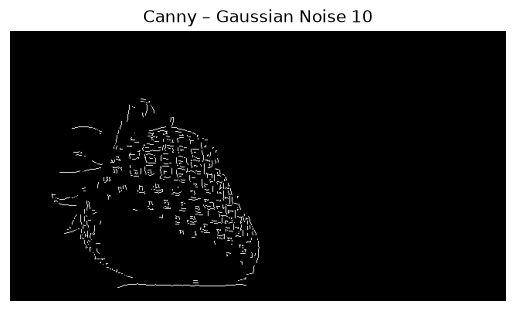

In [18]:
canny_g10 = canny_scratch(gaussian10, 100, 200)

plt.imshow(canny_g10, cmap="gray")
plt.title("Canny – Gaussian Noise 10")
plt.axis("off")
plt.show()

## Canny Gaussian 10 Matrix

In [19]:
print("Canny Gaussian 10 Matrix:")
print(canny_g10)

Canny Gaussian 10 Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Sobel – Scratch – Gaussian Noise 10

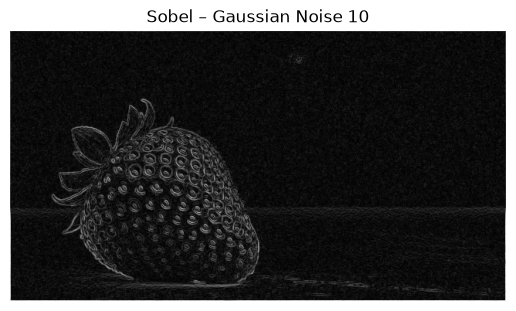

In [20]:
sobel_g10 = sobel_scratch(gaussian10)[2]

plt.imshow(sobel_g10, cmap="gray")
plt.title("Sobel – Gaussian Noise 10")
plt.axis("off")
plt.show()

## Sobel Gaussian 10 Matrix

In [21]:
print("Sobel Gaussian 10 Matrix:")
print(sobel_g10)

Sobel Gaussian 10 Matrix:
[[274.02189694 249.14654322 277.2002886  ... 290.99140881 312.31394461
  286.44720281]
 [265.93232222 100.65783626  38.83297568 ...  40.19950248  70.21395873
  297.06901555]
 [233.17375496  50.59644256  39.59797975 ...  67.23094526  67.67569726
  310.41262861]
 ...
 [781.61499474  32.24903099  86.127812   ...  30.          41.23105626
  893.06774659]
 [802.20196958  55.02726597  67.67569726 ...  55.08175742  27.16615541
  910.01978   ]
 [908.11122667 839.05184584 846.05909959 ... 866.50216387 881.00056754
  951.80355116]]


## Module – Gaussian Noise 30

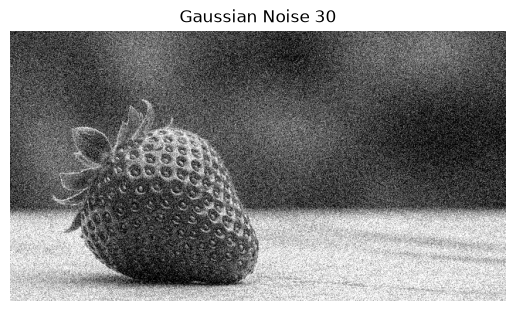

In [ ]:
noise30 = np.random.normal(0, 30, img.shape)
gaussian30 = np.uint8(np.clip(img + noise30, 0, 255))

plt.imshow(gaussian30, cmap="gray")
plt.title("Gaussian Noise 30")
plt.axis("off")
plt.show()

## Gaussian Noise 30 Matrix

In [ ]:
print("Gaussian Noise 30 Matrix:")
print(gaussian30)

Gaussian Noise 30 Matrix:
[[ 37  78 105 ...  34  71  39]
 [ 48   7 121 ...  62  93 104]
 [ 67  44  64 ...  77  57  33]
 ...
 [222 237 215 ... 216 255 252]
 [197 241 105 ... 198 203 211]
 [242 207 255 ... 223 217 227]]


## Canny – Scratch – Gaussian Noise 30

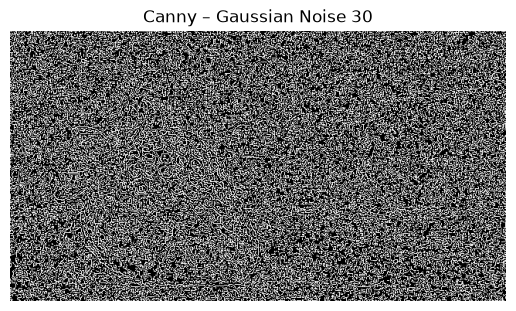

In [ ]:
canny_g30 = canny_scratch(gaussian30, 100, 200)

plt.imshow(canny_g30, cmap="gray")
plt.title("Canny – Gaussian Noise 30")
plt.axis("off")
plt.show()

## Canny Gaussian 30 Matrix

In [ ]:
print("Canny Gaussian 30 Matrix:")
print(canny_g30)

Canny Gaussian 30 Matrix:
[[255 255   0 ... 255 255 255]
 [  0 255   0 ... 255   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [255 255 255 ...   0   0   0]
 [  0 255   0 ...   0   0   0]
 [  0 255 255 ... 255   0   0]]


## Sobel – Scratch – Gaussian Noise 30

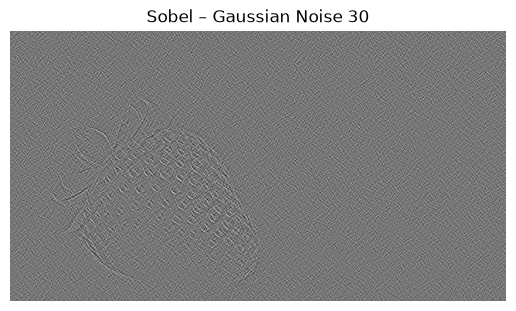

In [ ]:
sobel_g30 = sobel_scratch(gaussian30)[2]

plt.imshow(sobel_g30, cmap="gray")
plt.title("Sobel – Gaussian Noise 30")
plt.axis("off")
plt.show()

## Sobel Gaussian 30 Matrix

In [ ]:
print("Sobel Gaussian 30 Matrix:")
print(sobel_g30)

Sobel Gaussian 30 Matrix:
[[   0.    0.    0. ...    0.    0.    0.]
 [   0.  -71.   39. ...  -44.  -49.    0.]
 [   0.  -83. -135. ...  -57.  -50.    0.]
 ...
 [   0.  -92.   35. ...   19.   31.    0.]
 [   0.   20.   12. ...  -31.  -32.    0.]
 [   0.    0.    0. ...    0.    0.    0.]]


## Module – Gaussian Noise 50

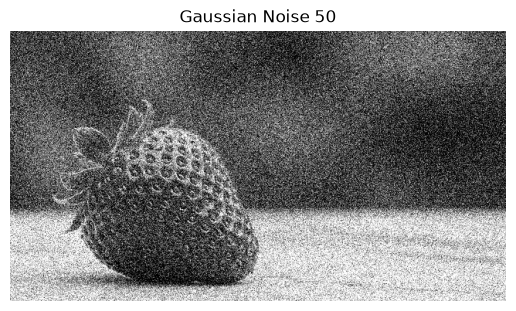

In [ ]:
noise50 = np.random.normal(0, 50, img.shape)
gaussian50 = np.uint8(np.clip(img + noise50, 0, 255))

plt.imshow(gaussian50, cmap="gray")
plt.title("Gaussian Noise 50")
plt.axis("off")
plt.show()

## Gaussian Noise 50 Matrix

In [ ]:
print("Gaussian Noise 50 Matrix:")
print(gaussian50)

Gaussian Noise 50 Matrix:
[[ 88  84  56 ...  60 132 113]
 [136  44  33 ...  59  42  78]
 [107 160  47 ...   0 120  34]
 ...
 [ 90 255 166 ... 101 237 196]
 [121 255 187 ... 210 190 180]
 [255 206 253 ... 174 255 191]]


## Canny – Scratch – Gaussian Noise 50

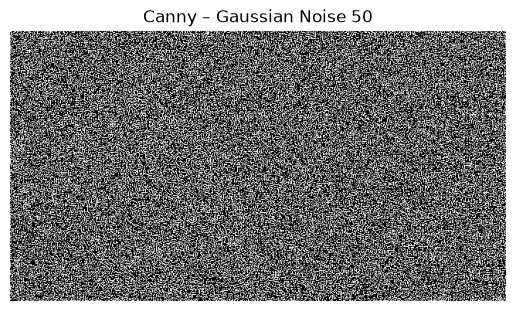

In [ ]:
canny_g50 = canny_scratch(gaussian50, 100, 200)

plt.imshow(canny_g50, cmap="gray")
plt.title("Canny – Gaussian Noise 50")
plt.axis("off")
plt.show()

## Canny Gaussian 50 Matrix

In [ ]:
print("Canny Gaussian 50 Matrix:")
print(canny_g50)

Canny Gaussian 50 Matrix:
[[255 255 255 ... 255   0   0]
 [255 255   0 ... 255   0 255]
 [  0 255   0 ...   0   0   0]
 ...
 [255   0   0 ...   0 255 255]
 [255   0 255 ... 255   0   0]
 [  0   0   0 ...   0   0 255]]


## Sobel – Scratch – Gaussian Noise 50

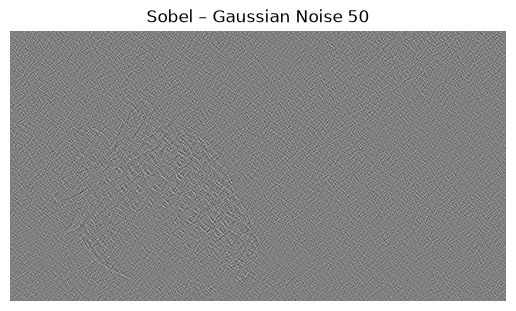

In [ ]:
sobel_g50 = sobel_scratch(gaussian50)[2]

plt.imshow(sobel_g50, cmap="gray")
plt.title("Sobel – Gaussian Noise 50")
plt.axis("off")
plt.show()

## Sobel Gaussian 50 Matrix

In [ ]:
print("Sobel Gaussian 50 Matrix:")
print(sobel_g50)

Sobel Gaussian 50 Matrix:
[[   0.    0.    0. ...    0.    0.    0.]
 [   0.  -28.  -61. ...   16.  -19.    0.]
 [   0.   25.    6. ...  -45.   42.    0.]
 ...
 [   0.  -22.  -47. ...    2. -171.    0.]
 [   0.  -78.   18. ...   -5.  -78.    0.]
 [   0.    0.    0. ...    0.    0.    0.]]


## Module – Salt & Pepper Noise 1%

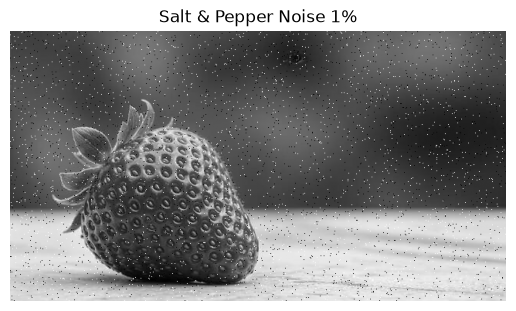

In [ ]:
sp1 = img.copy()

salt = np.random.rand(*img.shape) < 0.01
pepper = np.random.rand(*img.shape) < 0.01

sp1[salt] = 255
sp1[pepper] = 0

plt.imshow(sp1, cmap="gray")
plt.title("Salt & Pepper Noise 1%")
plt.axis("off")
plt.show()

## Salt & Pepper 1% Matrix

In [ ]:
print("Salt & Pepper 1% Matrix:")
print(sp1)

Salt & Pepper 1% Matrix:
[[ 62  67  67 ...  69  69  69]
 [ 61  65  65 ...  69  69  69]
 [ 59  63  63 ...  70  69  69]
 ...
 [217 216 215 ... 220 223 223]
 [219 218   0 ... 219 222 222]
 [220 219 219 ... 220 221 221]]


## Canny – Scratch – Salt & Pepper 1%

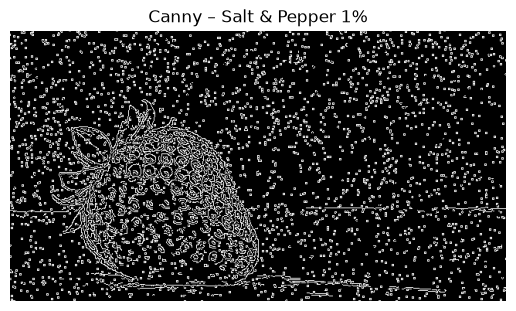

In [ ]:
canny_sp1 = canny_scratch(sp1, 100, 200)

plt.imshow(canny_sp1, cmap="gray")
plt.title("Canny – Salt & Pepper 1%")
plt.axis("off")
plt.show()

## Canny Salt & Pepper 1% Matrix

In [ ]:
print("Canny Salt & Pepper 1% Matrix:")
print(canny_sp1)

Canny Salt & Pepper 1% Matrix:
[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0 255 255 ...   0   0   0]
 [  0 255   0 ...   0   0   0]
 [  0 255 255 ...   0   0   0]]


## Sobel – Scratch – Salt & Pepper 1%

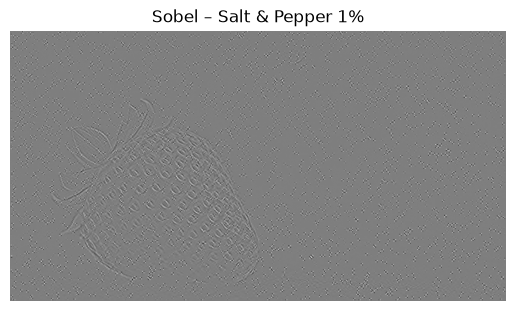

In [ ]:
sobel_sp1 = sobel_scratch(sp1)[2]

plt.imshow(sobel_sp1, cmap="gray")
plt.title("Sobel – Salt & Pepper 1%")
plt.axis("off")
plt.show()

## Sobel Salt & Pepper 1% Matrix

In [ ]:
print("Sobel Salt & Pepper 1% Matrix:")
print(sobel_sp1)

Sobel Salt & Pepper 1% Matrix:
[[   0.    0.    0. ...    0.    0.    0.]
 [   0.   -1.    4. ...    0.   -1.    0.]
 [   0.   -3.    5. ...    0.    0.    0.]
 ...
 [   0. -217.    0. ...    3.    3.    0.]
 [   0.    1.    1. ...   -1.   -2.    0.]
 [   0.    0.    0. ...    0.    0.    0.]]


## Module – Salt & Pepper Noise 3%

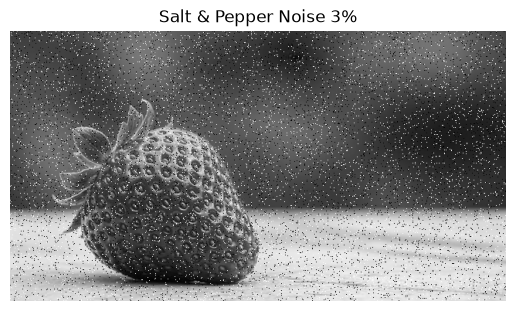

In [ ]:
sp3 = img.copy()

salt = np.random.rand(*img.shape) < 0.03
pepper = np.random.rand(*img.shape) < 0.03

sp3[salt] = 255
sp3[pepper] = 0

plt.imshow(sp3, cmap="gray")
plt.title("Salt & Pepper Noise 3%")
plt.axis("off")
plt.show()

## Salt & Pepper 3% Matrix

In [ ]:
print("Salt & Pepper 3% Matrix:")
print(sp3)

Salt & Pepper 3% Matrix:
[[ 62  67  67 ...  69  69  69]
 [ 61  65  65 ...   0  69  69]
 [ 59 255  63 ...  70  69  69]
 ...
 [217 216 215 ... 220 223 223]
 [219 218 217 ... 219 222 222]
 [220 219 219 ... 220 221 221]]


## Canny – Scratch – Salt & Pepper 3%

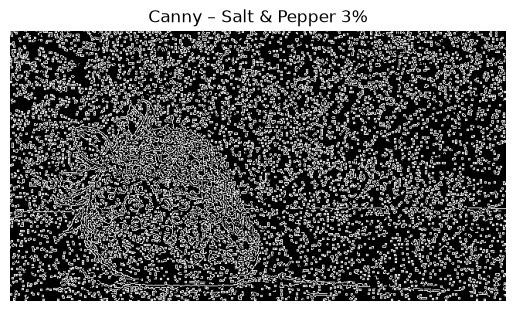

In [ ]:
canny_sp3 = canny_scratch(sp3, 100, 200)

plt.imshow(canny_sp3, cmap="gray")
plt.title("Canny – Salt & Pepper 3%")
plt.axis("off")
plt.show()

## Canny Salt & Pepper 3% Matrix

In [ ]:
print("Canny Salt & Pepper 3% Matrix:")
print(canny_sp3)

Canny Salt & Pepper 3% Matrix:
[[  0   0   0 ...   0   0   0]
 [255 255   0 ...   0   0   0]
 [255   0 255 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


## Sobel – Scratch – Salt & Pepper 3%

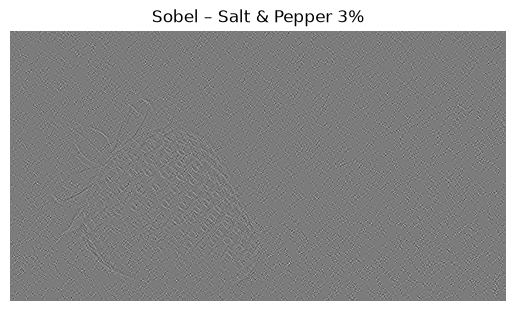

In [ ]:
sobel_sp3 = sobel_scratch(sp3)[2]

plt.imshow(sobel_sp3, cmap="gray")
plt.title("Sobel – Salt & Pepper 3%")
plt.axis("off")
plt.show()

## Sobel Salt & Pepper 3% Matrix

In [ ]:
print("Sobel Salt & Pepper 3% Matrix:")
print(sobel_sp3)

Sobel Salt & Pepper 3% Matrix:
[[   0.    0.    0. ...    0.    0.    0.]
 [   0.   -1. -188. ...    0.   -1.    0.]
 [   0.   -3.    5. ...    0.  -69.    0.]
 ...
 [   0.   38.    0. ...    3.    3.    0.]
 [   0.    1.    1. ...   -1.   -2.    0.]
 [   0.    0.    0. ...    0.    0.    0.]]


## Module – Salt & Pepper Noise 5%

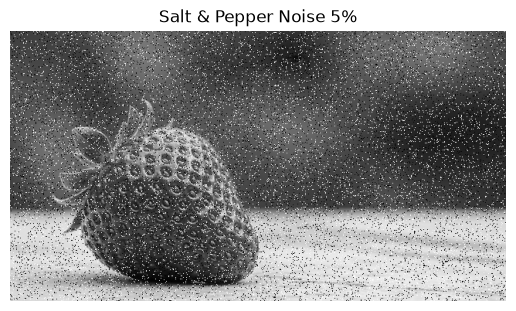

In [ ]:
sp5 = img.copy()

salt = np.random.rand(*img.shape) < 0.05
pepper = np.random.rand(*img.shape) < 0.05

sp5[salt] = 255
sp5[pepper] = 0

plt.imshow(sp5, cmap="gray")
plt.title("Salt & Pepper Noise 5%")
plt.axis("off")
plt.show()

## Salt & Pepper 5% Matrix

In [ ]:
print("Salt & Pepper 5% Matrix:")
print(sp5)

Salt & Pepper 5% Matrix:
[[ 62  67  67 ... 255  69  69]
 [  0  65  65 ...  69 255  69]
 [ 59  63  63 ...  70  69  69]
 ...
 [  0 216 215 ... 220 223 223]
 [219 218   0 ... 219 222 222]
 [220 219 219 ... 220 221 221]]


## Canny – Scratch – Salt & Pepper 5%

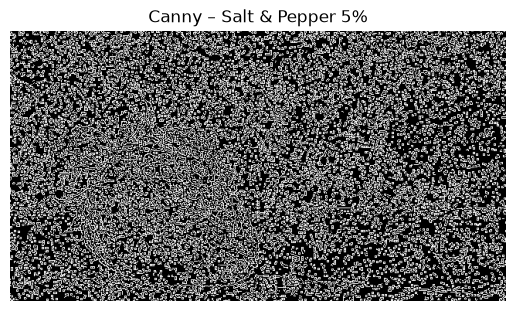

In [ ]:
canny_sp5 = canny_scratch(sp5, 100, 200)

plt.imshow(canny_sp5, cmap="gray")
plt.title("Canny – Salt & Pepper 5%")
plt.axis("off")
plt.show()

## Canny Salt & Pepper 5% Matrix

In [ ]:
print("Canny Salt & Pepper 5% Matrix:")
print(canny_sp5)

Canny Salt & Pepper 5% Matrix:
[[255   0   0 ... 255 255   0]
 [  0 255   0 ...   0 255   0]
 [  0 255 255 ...   0   0   0]
 ...
 [255   0 255 ... 255   0   0]
 [255 255   0 ... 255   0   0]
 [  0 255 255 ... 255   0   0]]


## Sobel – Scratch – Salt & Pepper 5%

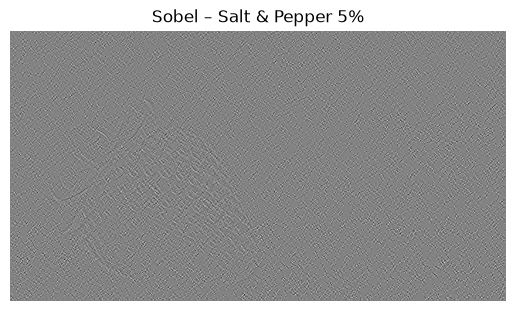

In [ ]:
sobel_sp5 = sobel_scratch(sp5)[2]

plt.imshow(sobel_sp5, cmap="gray")
plt.title("Sobel – Salt & Pepper 5%")
plt.axis("off")
plt.show()

## Sobel Salt & Pepper 5% Matrix

In [ ]:
print("Sobel Salt & Pepper 5% Matrix:")
print(sobel_sp5)

Sobel Salt & Pepper 5% Matrix:
[[   0.    0.    0. ...    0.    0.    0.]
 [   0.   -1.    4. ...    0.  185.    0.]
 [   0.  -64.   66. ... -186.    0.    0.]
 ...
 [   0. -217.    0. ...  221.    3.    0.]
 [   0. -216.    1. ...   -1.   -2.    0.]
 [   0.    0.    0. ...    0.    0.    0.]]


## Module – Complete

In [ ]:
print("All image-processing modules completed.")

All image-processing modules completed.
